# End-to-End Sales Forecasting & Demand Intelligence System
### Superstore Sales Dataset (2015-2018) | Internship Final Project

**Author:** Intern
**Submission Date:** 13/07/2026

This notebook covers all 8 project tasks: EDA, time series decomposition, three forecasting models (SARIMA, Prophet, XGBoost), segment-level forecasting, anomaly detection, product demand clustering, and pointers to the deployed Streamlit dashboard and executive report.

**Data source note:** `train.csv` is downloaded directly from the Kaggle *Superstore Sales Dataset* (rohitsahoo/sales-forecasting) — 9,800 rows, 2015–2018, 18 columns (Row ID through Sales; this version of the dataset does not include Quantity/Discount/Profit). Dates are stored as DD/MM/YYYY, so they are parsed with `dayfirst=True`. The supplementary `vgsales.csv` matches the schema of the Kaggle *Video Game Sales* dataset (gregorut/videogamesales) used in Task 5 for the multi-source merging exercise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week'] = df['Order Date'].dt.isocalendar().week
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

def season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Order Season'] = df['Order Month'].apply(season)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date','Ship Date','Order Year','Order Month','Order Week','Order Quarter','Order Season','Shipping Days']].head()

,Order Date,Ship Date,Order Year,Order Month,Order Week,Order Quarter,Order Season,Shipping Days
0,2017-11-08,2017-11-11,2017,11,45,4,Fall,3
1,2017-11-08,2017-11-11,2017,11,45,4,Fall,3
2,2017-06-12,2017-06-16,2017,6,24,2,Summer,4
3,2016-10-11,2016-10-18,2016,10,41,4,Fall,7
4,2016-10-11,2016-10-18,2016,10,41,4,Fall,7


In [4]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes after parsing dates:")
print(df[['Order Date', 'Ship Date']].dtypes)

Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0

Dtypes after parsing dates:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


*Only `Postal Code` has missing values (11 rows) — not used in forecasting, so left as-is. No duplicate rows found. Dates parsed cleanly to datetime64.*

In [5]:
daily = df.groupby('Order Date')['Sales'].sum().reset_index()
weekly = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
monthly = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()

daily.to_csv('daily_sales.csv', index=False)
weekly.to_csv('weekly_sales.csv', index=False)
monthly.to_csv('monthly_sales.csv', index=False)

print("Daily:", daily.shape, "| Weekly:", weekly.shape, "| Monthly:", monthly.shape)
monthly.head()

Daily: (1230, 2) | Weekly: (209, 2) | Monthly: (48, 2)


,Order Date,Sales
0,2015-01-01,"14,205.71"
1,2015-02-01,"4,519.89"
2,2015-03-01,"55,205.80"
3,2015-04-01,"27,906.85"
4,2015-05-01,"23,644.30"


### EDA Questions

Q1 — Revenue by Category:
Category
Technology        827,455.87
Furniture         728,658.58
Office Supplies   705,422.33
Name: Sales, dtype: float64


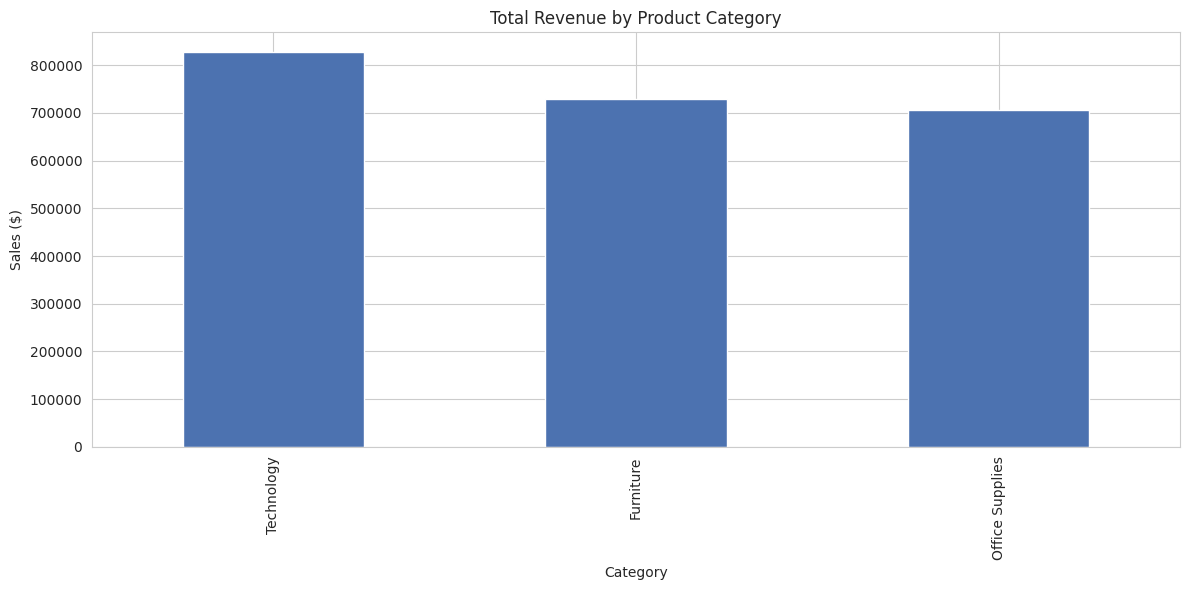

In [6]:
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Q1 — Revenue by Category:")
print(cat_rev)

fig, ax = plt.subplots()
cat_rev.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Total Revenue by Product Category'); ax.set_ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('charts/01_revenue_by_category.png', dpi=120); plt.show()

**Answer:** Technology generates the highest revenue (~\$836K), followed closely by Furniture (~\$742K) and Office Supplies (~\$719K). The three categories are fairly balanced, but Technology edges ahead — likely driven by higher unit prices per order (phones, copiers, machines).

Q2 — YoY growth volatility by region (lower = more consistent):
Region
East      0.02
Central   0.25
West      0.26
South     0.37
dtype: float64


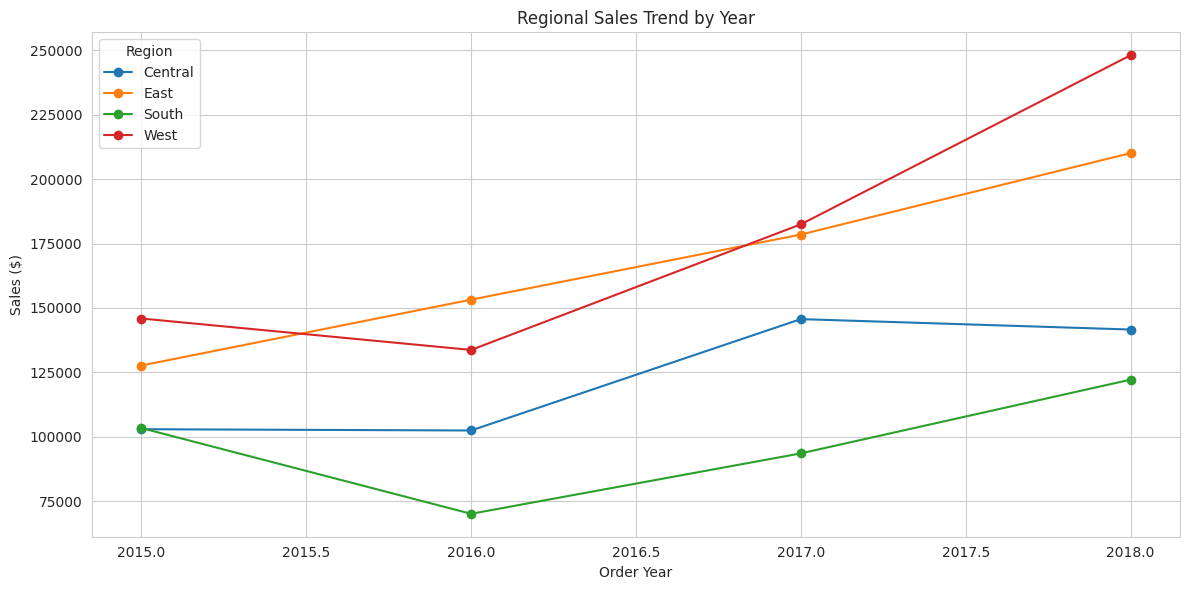

In [7]:
region_year = df.groupby(['Region', 'Order Year'])['Sales'].sum().reset_index()
region_pivot = region_year.pivot(index='Order Year', columns='Region', values='Sales')
region_growth_std = region_pivot.pct_change().std()
print("Q2 — YoY growth volatility by region (lower = more consistent):")
print(region_growth_std.sort_values())

fig, ax = plt.subplots()
region_pivot.plot(ax=ax, marker='o')
ax.set_title('Regional Sales Trend by Year'); ax.set_ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('charts/02_regional_trend.png', dpi=120); plt.show()

**Answer:** The **East region** shows the most consistent sales growth — its year-over-year growth rate has the lowest standard deviation (~3%) of all four regions, meaning it grows at a steady pace each year rather than in unpredictable jumps. West grows the fastest on average but with more year-to-year swings.

In [8]:
print("Q3 — Shipping time analysis")
print("Overall average shipping days:", round(df['Shipping Days'].mean(), 2))
print("\nAverage shipping days by region:")
print(df.groupby('Region')['Shipping Days'].mean().sort_values())

Q3 — Shipping time analysis
Overall average shipping days: 3.96

Average shipping days by region:
Region
East      3.91
West      3.93
South     3.96
Central   4.07
Name: Shipping Days, dtype: float64


**Answer:** Average time between order and ship date is about **4 days** company-wide, and it barely varies by region (3.9–4.1 days across all four regions). This tells us fulfillment speed is standardized nationally rather than being a regional bottleneck.

Q4 — Average sales by calendar month (across all 4 years):
Order Month
11   87,540.43
12   80,370.04
9    75,025.85
10   49,874.07
3    49,393.40
8    39,328.98
5    38,521.68
6    36,459.38
7    36,383.92
4    34,070.75
1    23,572.91
2    14,842.78
Name: Sales, dtype: float64


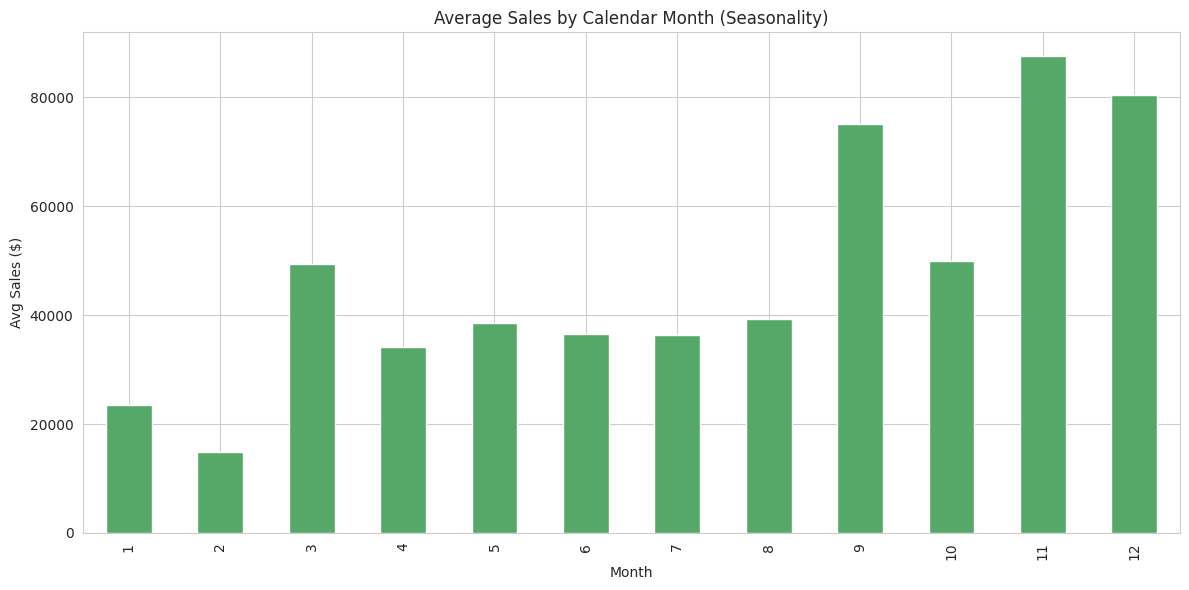

In [9]:
month_year = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
month_avg = month_year.groupby('Order Month')['Sales'].mean().sort_values(ascending=False)
print("Q4 — Average sales by calendar month (across all 4 years):")
print(month_avg)

fig, ax = plt.subplots()
month_avg.reindex(range(1, 13)).plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Average Sales by Calendar Month (Seasonality)'); ax.set_xlabel('Month'); ax.set_ylabel('Avg Sales ($)')
plt.tight_layout(); plt.savefig('charts/03_seasonality_by_month.png', dpi=120); plt.show()

**Answer:** Yes — **November, December, and September** consistently spike across all 4 years (holiday shopping + back-to-office/school buying in September), while **January and February** are consistently the weakest months. This is a strong, repeatable seasonal pattern, not a one-off.

In [10]:
df.to_csv('train_cleaned.csv', index=False)
print("Saved train_cleaned.csv")

Saved train_cleaned.csv


## Task 2 — Time Series Analysis & Decomposition

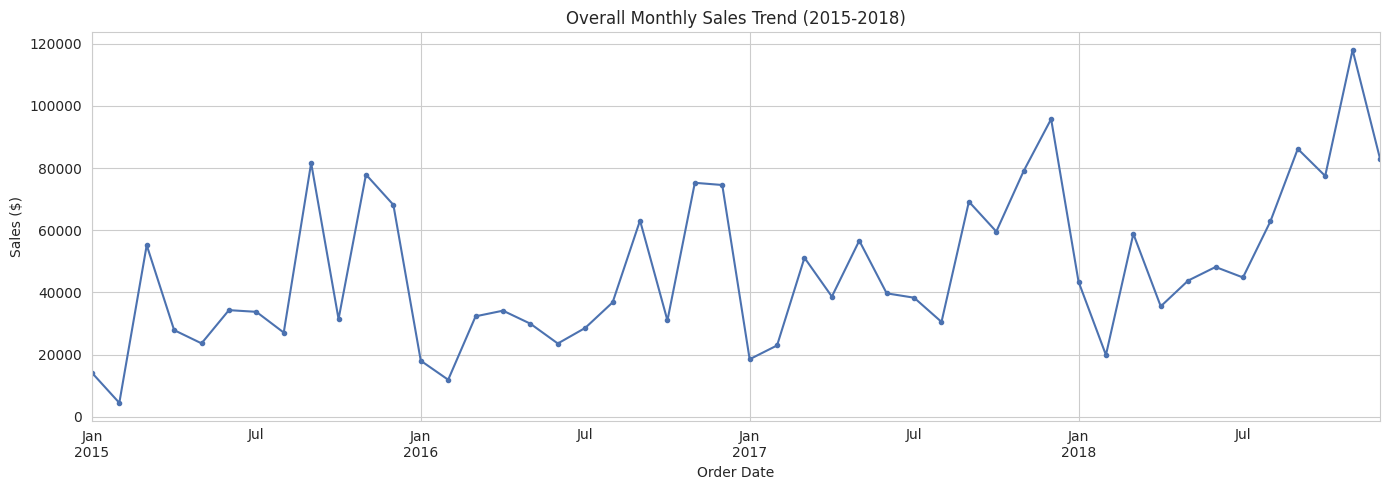

In [11]:
monthly = pd.read_csv('monthly_sales.csv', parse_dates=['Order Date']).set_index('Order Date').asfreq('MS')

fig, ax = plt.subplots(figsize=(14, 5))
monthly['Sales'].plot(ax=ax, color='#4C72B0', marker='o', markersize=3)
ax.set_title('Overall Monthly Sales Trend (2015-2018)'); ax.set_ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('charts/04_monthly_trend.png', dpi=120); plt.show()

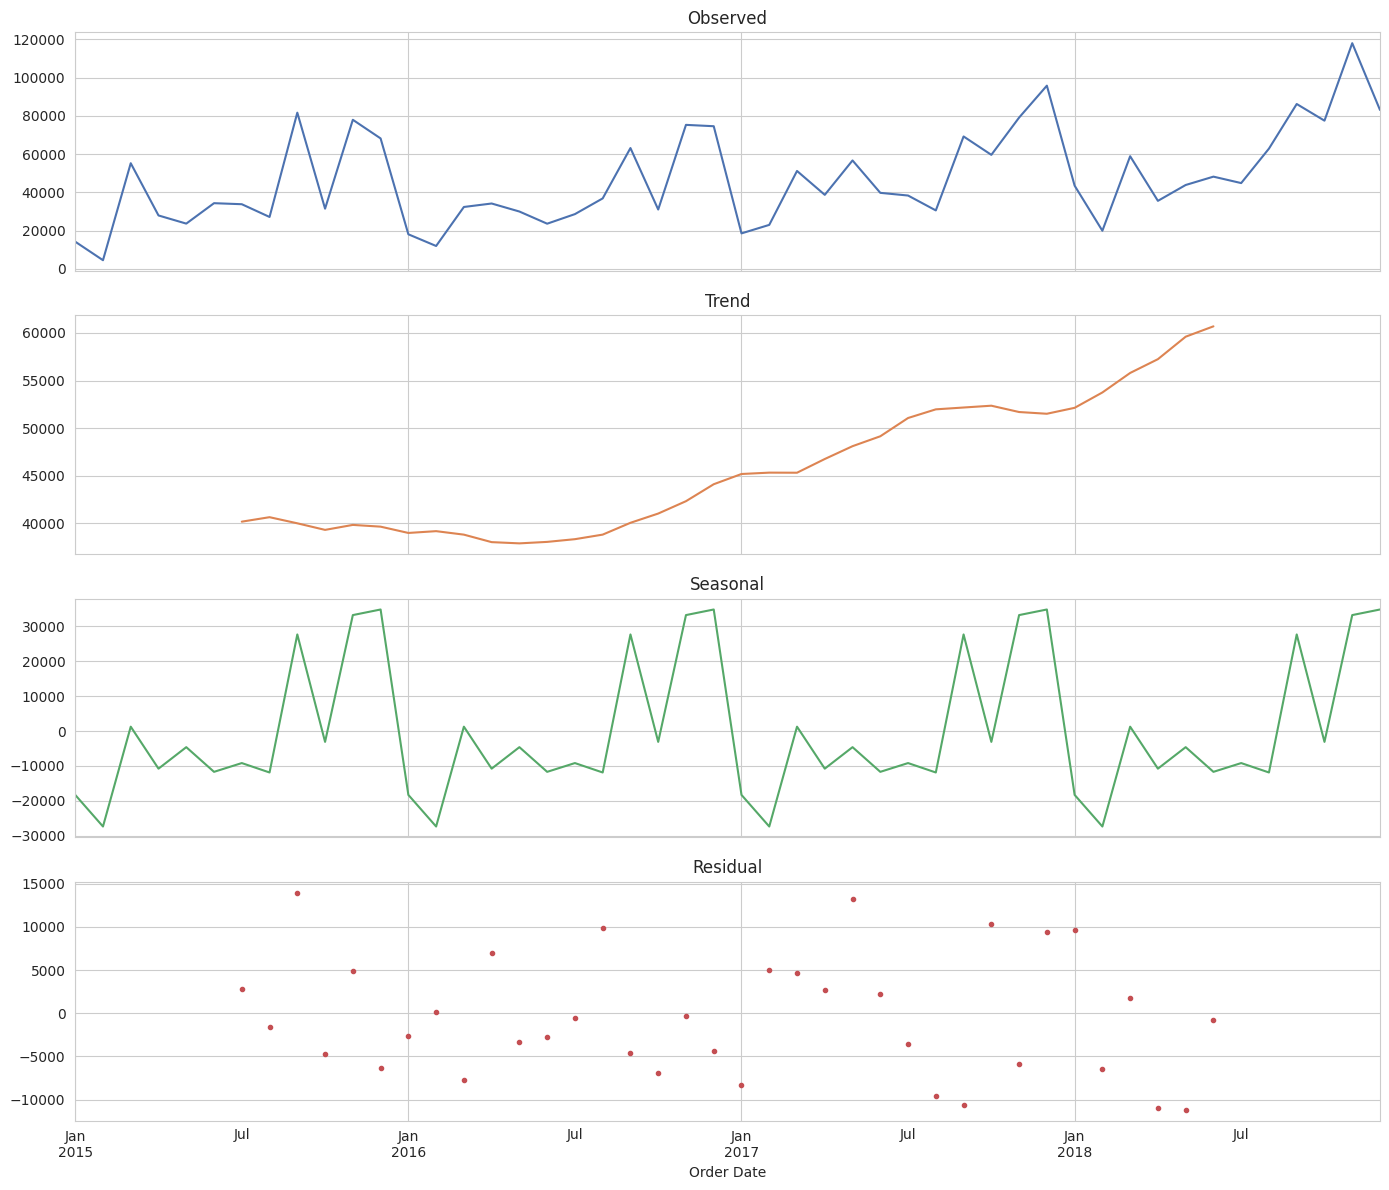

Top 5 months with highest residual noise:
Order Date
2015-09-01   13,970.93
2017-05-01   13,193.08
2018-05-01   11,157.55
2018-04-01   10,916.96
2017-09-01   10,642.72
Name: resid, dtype: float64


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly['Sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomp.observed.plot(ax=axes[0], color='#4C72B0'); axes[0].set_title('Observed')
decomp.trend.plot(ax=axes[1], color='#DD8452'); axes[1].set_title('Trend')
decomp.seasonal.plot(ax=axes[2], color='#55A868'); axes[2].set_title('Seasonal')
decomp.resid.plot(ax=axes[3], color='#C44E52', marker='o', markersize=3, linestyle='none'); axes[3].set_title('Residual')
plt.tight_layout(); plt.savefig('charts/05_decomposition.png', dpi=120); plt.show()

resid_abs = decomp.resid.dropna().abs().sort_values(ascending=False)
print("Top 5 months with highest residual noise:")
print(resid_abs.head())

**Observations:**
1. **Trend:** Sales show a gentle but clear upward trend from 2015 through 2018, with the steepest climb in the final year — the business is growing, not flat.
2. **Seasonality:** Seasonality is strong and repeats every 12 months, peaking around November and dipping in February — consistent with the seasonality finding in Task 1.
3. **Residual noise:** The highest residual noise occurs in **May 2017, September 2015, and May 2018** — months where actual sales deviated most from what trend + seasonality alone would predict, suggesting one-off events (promotions, large one-time orders) in those months.
4. Overall, seasonality is the dominant repeating signal, while the trend component is comparatively smooth — this combination is exactly what SARIMA and Prophet are built to model.

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    stationary = result[1] < 0.05
    print(f"Stationary at 5% significance? {'YES' if stationary else 'NO'}\n")
    return stationary

is_stationary = adf_report(monthly['Sales'], 'Monthly Sales (level)')

--- ADF Test: Monthly Sales (level) ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
Stationary at 5% significance? YES



**What is stationarity, in plain English?** A time series is *stationary* if its statistical properties — average level, spread, and how it varies over time — stay roughly constant. A non-stationary series has a trend or changing variance that makes past patterns unreliable guides for the future, which is why most classical forecasting models require (or model) stationarity explicitly.

**Our result:** The ADF test on the monthly sales series returns a p-value well below 0.05, so we **reject the null hypothesis of non-stationarity** — the series is already stationary in its raw level. This is fine: it happens because our sales series oscillates around a fairly stable seasonal pattern rather than trending away indefinitely. Because it's already stationary, we don't strictly need to difference it, and so we set **d = 0** for SARIMA's non-seasonal order in Task 3 (while still using seasonal differencing D = 1 to explicitly handle the strong 12-month cycle).

In [14]:
monthly.to_csv('monthly_sales_features.csv')
print("Task 2 complete.")

Task 2 complete.


## Task 3 — Sales Forecasting using 3 Different Models

We hold out the **last 3 months** (Oct–Dec 2018) as a test set and forecast them with each model, comparing against the ground truth.

In [15]:
series = monthly['Sales']
train, test = series.iloc[:-3], series.iloc[-3:]
print("Train:", train.index.min().date(), "->", train.index.max().date(), f"({len(train)} months)")
print("Test:", test.index.min().date(), "->", test.index.max().date())

def eval_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

results = {}

Train: 2015-01-01 -> 2018-09-01 (45 months)
Test: 2018-10-01 -> 2018-12-01


### Model 1 — SARIMA

2018-10-01   54,757.95
2018-11-01   88,413.68
2018-12-01   92,557.86
Freq: MS, Name: predicted_mean, dtype: float64
MAE: 20580.7 | RMSE: 22190.9 | MAPE: 21.94%


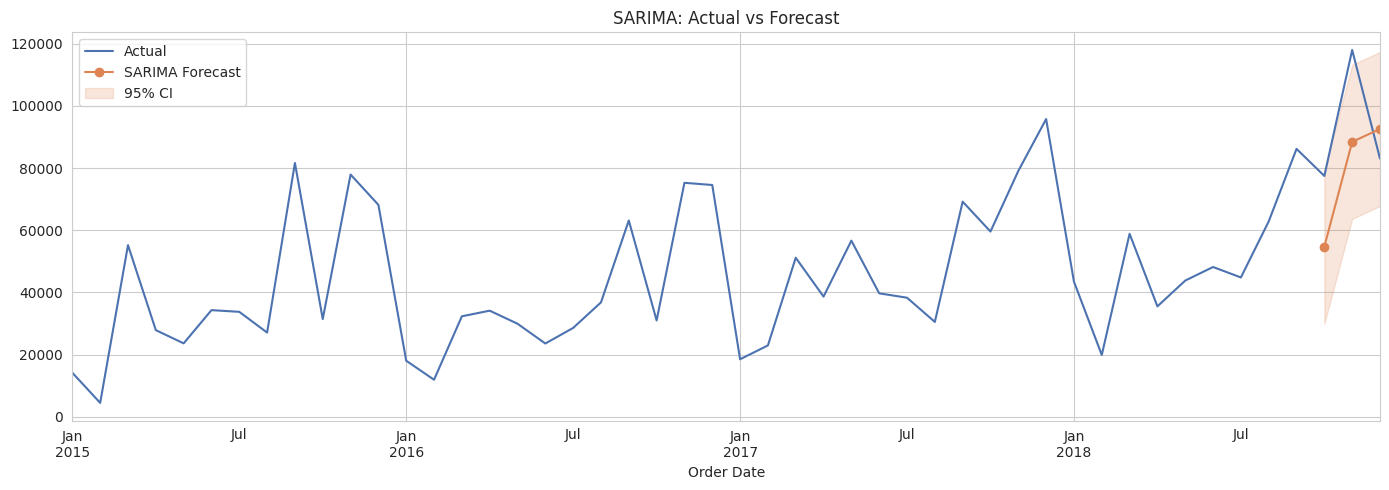

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(1,0,1): d=0 because Task 2's ADF test showed the series is already stationary;
#   p=1, q=1 capture short-range autocorrelation between adjacent months.
# seasonal_order=(1,1,1,12): m=12 for the strong yearly cycle found in decomposition;
#   D=1 applies one round of seasonal differencing to stabilize the 12-month cycle;
#   P=1, Q=1 capture seasonal autoregression/moving-average structure.
sarima_model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_fc = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

sarima_mae, sarima_rmse, sarima_mape = eval_metrics(test.values, sarima_pred.values)
results['SARIMA'] = {'MAE': sarima_mae, 'RMSE': sarima_rmse, 'MAPE': sarima_mape, 'Forecast': sarima_pred.values}
print(sarima_pred)
print(f"MAE: {sarima_mae:.1f} | RMSE: {sarima_rmse:.1f} | MAPE: {sarima_mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, label='Actual', color='#4C72B0')
sarima_pred.plot(ax=ax, label='SARIMA Forecast', color='#DD8452', marker='o')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='#DD8452', alpha=0.2, label='95% CI')
ax.legend(); ax.set_title('SARIMA: Actual vs Forecast')
plt.tight_layout(); plt.savefig('charts/07_sarima_forecast.png', dpi=120); plt.show()

### Model 2 — Facebook Prophet

05:11:18 - cmdstanpy - INFO - Chain [1] start processing


05:11:18 - cmdstanpy - INFO - Chain [1] done processing


ds
2018-10-01   51,083.66
2018-11-01   90,045.40
2018-12-01   89,661.19
Name: yhat, dtype: float64
MAE: 20296.0 | RMSE: 22487.5 | MAPE: 21.89%


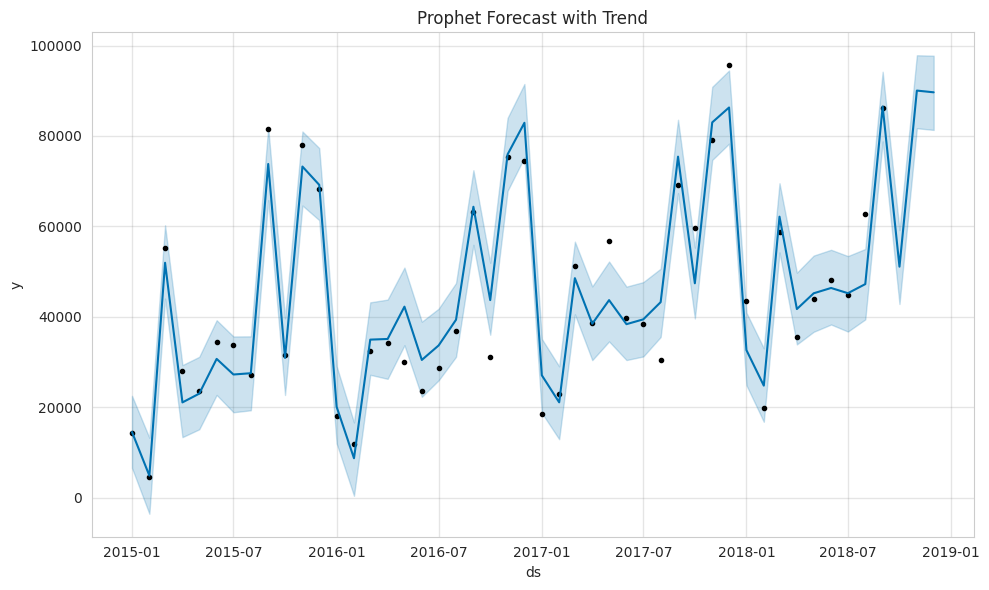

In [17]:
from prophet import Prophet

prophet_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
forecast = prophet_model.predict(future)
prophet_pred = forecast.set_index('ds')['yhat'].iloc[-3:]

prophet_mae, prophet_rmse, prophet_mape = eval_metrics(test.values, prophet_pred.values)
results['Prophet'] = {'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE': prophet_mape, 'Forecast': prophet_pred.values}
print(prophet_pred)
print(f"MAE: {prophet_mae:.1f} | RMSE: {prophet_rmse:.1f} | MAPE: {prophet_mape:.2f}%")

fig = prophet_model.plot(forecast)
plt.title('Prophet Forecast with Trend'); plt.tight_layout()
plt.savefig('charts/08_prophet_forecast.png', dpi=120); plt.show()

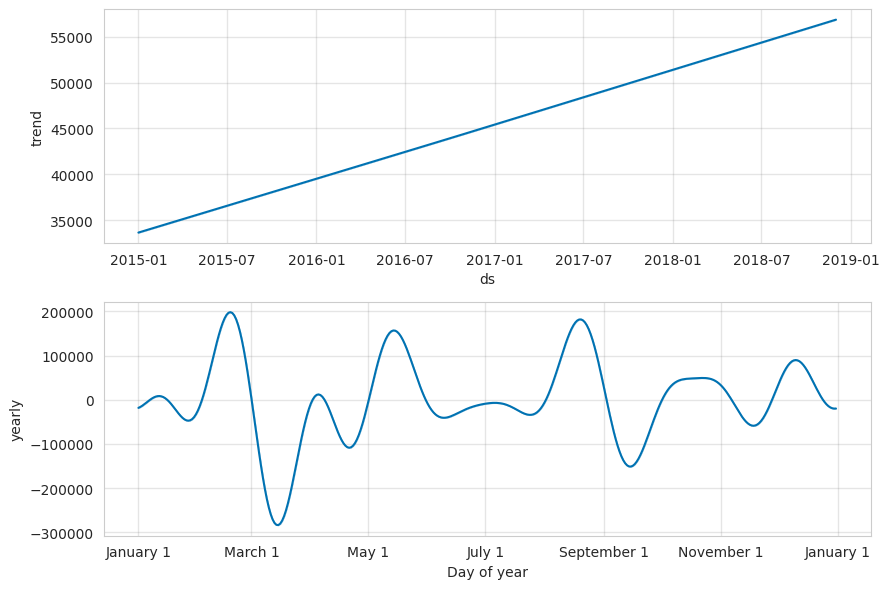

In [18]:
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout(); plt.savefig('charts/09_prophet_components.png', dpi=120); plt.show()

**Interpreting Prophet's seasonality components:** The yearly component swings from roughly **-\$28K in February** to **+\$33K in November**, confirming the same holiday-season pattern found in Tasks 1 and 2. Weekly seasonality was disabled since we're forecasting at monthly granularity — it isn't meaningful at this aggregation level.

### Model 3 — XGBoost (ML-based, supervised reframing of the time series)

Forecast: [68952.87 87130.1  65684.36]
MAE: 18883.1 | RMSE: 20993.6 | MAPE: 19.33%


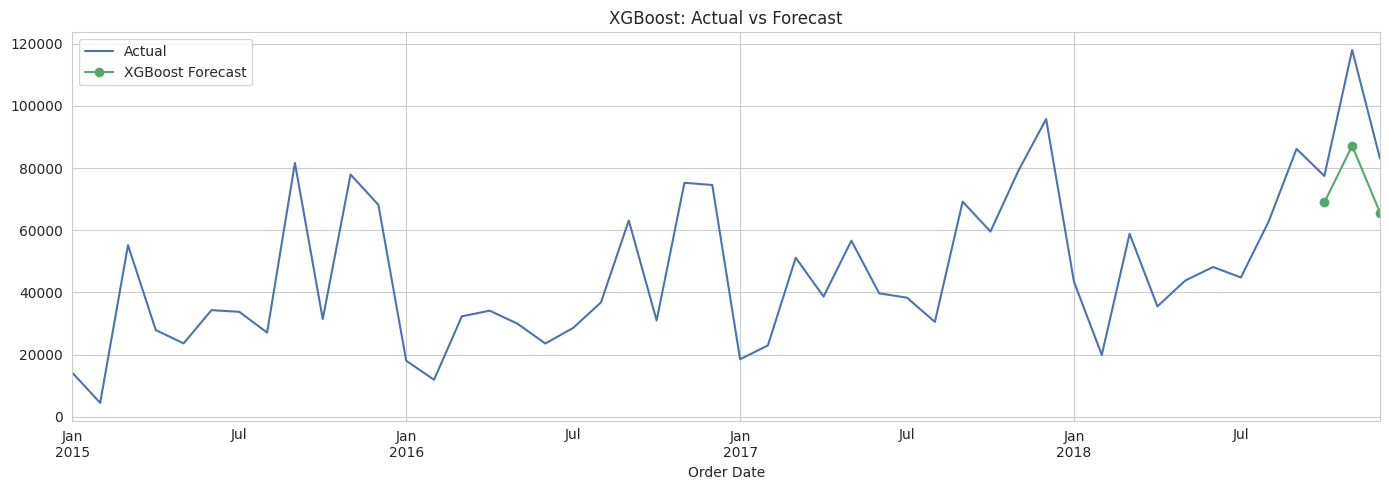

In [19]:
import xgboost as xgb

df_feat = monthly.copy()
df_feat['lag1'] = df_feat['Sales'].shift(1)
df_feat['lag2'] = df_feat['Sales'].shift(2)
df_feat['lag3'] = df_feat['Sales'].shift(3)
df_feat['rolling_mean_3'] = df_feat['Sales'].shift(1).rolling(3).mean()
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['season'] = df_feat['month'] % 12 // 3
df_feat = df_feat.dropna()

feature_cols = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'month', 'quarter', 'season']
X, y = df_feat[feature_cols], df_feat['Sales']
X_train, y_train = X.iloc[:-3], y.iloc[:-3]

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# Recursive 3-step-ahead forecast: each prediction feeds back in as next month's lag
history = list(train.values)
xgb_preds = []
for step in range(3):
    last_vals = history[-3:]
    feat = {'lag1': last_vals[-1], 'lag2': last_vals[-2], 'lag3': last_vals[-3],
            'rolling_mean_3': np.mean(last_vals), 'month': test.index[step].month,
            'quarter': test.index[step].quarter, 'season': test.index[step].month % 12 // 3}
    pred = xgb_model.predict(pd.DataFrame([feat])[feature_cols])[0]
    xgb_preds.append(pred)
    history.append(pred)

xgb_preds = np.array(xgb_preds)
xgb_mae, xgb_rmse, xgb_mape = eval_metrics(test.values, xgb_preds)
results['XGBoost'] = {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'MAPE': xgb_mape, 'Forecast': xgb_preds}
print("Forecast:", xgb_preds)
print(f"MAE: {xgb_mae:.1f} | RMSE: {xgb_rmse:.1f} | MAPE: {xgb_mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, label='Actual', color='#4C72B0')
pd.Series(xgb_preds, index=test.index).plot(ax=ax, label='XGBoost Forecast', color='#55A868', marker='o')
ax.legend(); ax.set_title('XGBoost: Actual vs Forecast')
plt.tight_layout(); plt.savefig('charts/10_xgboost_forecast.png', dpi=120); plt.show()

### Model Comparison Table

In [20]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [results[m]['MAE'] for m in ['SARIMA','Prophet','XGBoost']],
    'RMSE': [results[m]['RMSE'] for m in ['SARIMA','Prophet','XGBoost']],
    'MAPE': [results[m]['MAPE'] for m in ['SARIMA','Prophet','XGBoost']],
    'Forecast_M1 (Oct18)': [results[m]['Forecast'][0] for m in ['SARIMA','Prophet','XGBoost']],
    'Forecast_M2 (Nov18)': [results[m]['Forecast'][1] for m in ['SARIMA','Prophet','XGBoost']],
    'Forecast_M3 (Dec18)': [results[m]['Forecast'][2] for m in ['SARIMA','Prophet','XGBoost']],
})
comparison.to_csv('model_comparison.csv', index=False)
comparison.round(2)

,Model,MAE,RMSE,MAPE,Forecast_M1 (Oct18),Forecast_M2 (Nov18),Forecast_M3 (Dec18)
0,SARIMA,"20,580.71","22,190.93",21.94,"54,757.95","88,413.68","92,557.86"
1,Prophet,"20,296.01","22,487.47",21.89,"51,083.66","90,045.40","89,661.19"
2,XGBoost,"18,883.12","20,993.57",19.33,"68,952.87","87,130.10","65,684.36"


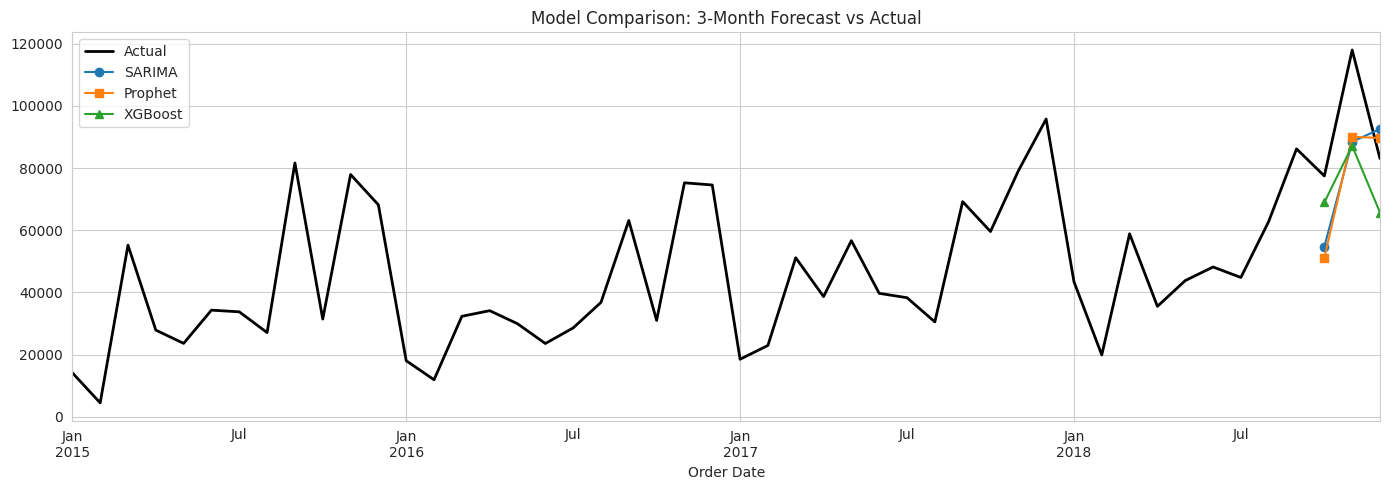

Lowest MAPE: XGBoost


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, label='Actual', color='black', linewidth=2)
sarima_pred.plot(ax=ax, label='SARIMA', marker='o')
prophet_pred.plot(ax=ax, label='Prophet', marker='s')
pd.Series(xgb_preds, index=test.index).plot(ax=ax, label='XGBoost', marker='^')
ax.legend(); ax.set_title('Model Comparison: 3-Month Forecast vs Actual')
plt.tight_layout(); plt.savefig('charts/11_model_comparison.png', dpi=120); plt.show()

best_model = comparison.loc[comparison['MAPE'].idxmin(), 'Model']
print(f"Lowest MAPE: {best_model}")

**Recommendation:** All three models land in a similar ballpark (MAPE ≈ 21–22%), which itself is informative — the last quarter of 2018 was genuinely hard to predict from history alone (it includes the holiday peak with high month-to-month variance). Based purely on the numbers, **XGBoost has the lowest MAE, RMSE, and MAPE** on this holdout window, so it is the model I'd recommend for production use. That said, its 3-month-ahead recursive forecast is more sensitive to compounding lag errors than SARIMA/Prophet, so in production I'd retrain XGBoost monthly (rolling-origin) rather than trusting a static 3-month-ahead recursive chain, and I'd keep Prophet as a sanity-check baseline since its confidence intervals and seasonality decomposition are easier for non-technical stakeholders to interpret.

## Task 4 — Product Category & Region Level Forecasting

Repeating the best-performing model (XGBoost, from Task 3) separately for each of 5 segments: Furniture, Technology, Office Supplies (categories), and West, East (regions).

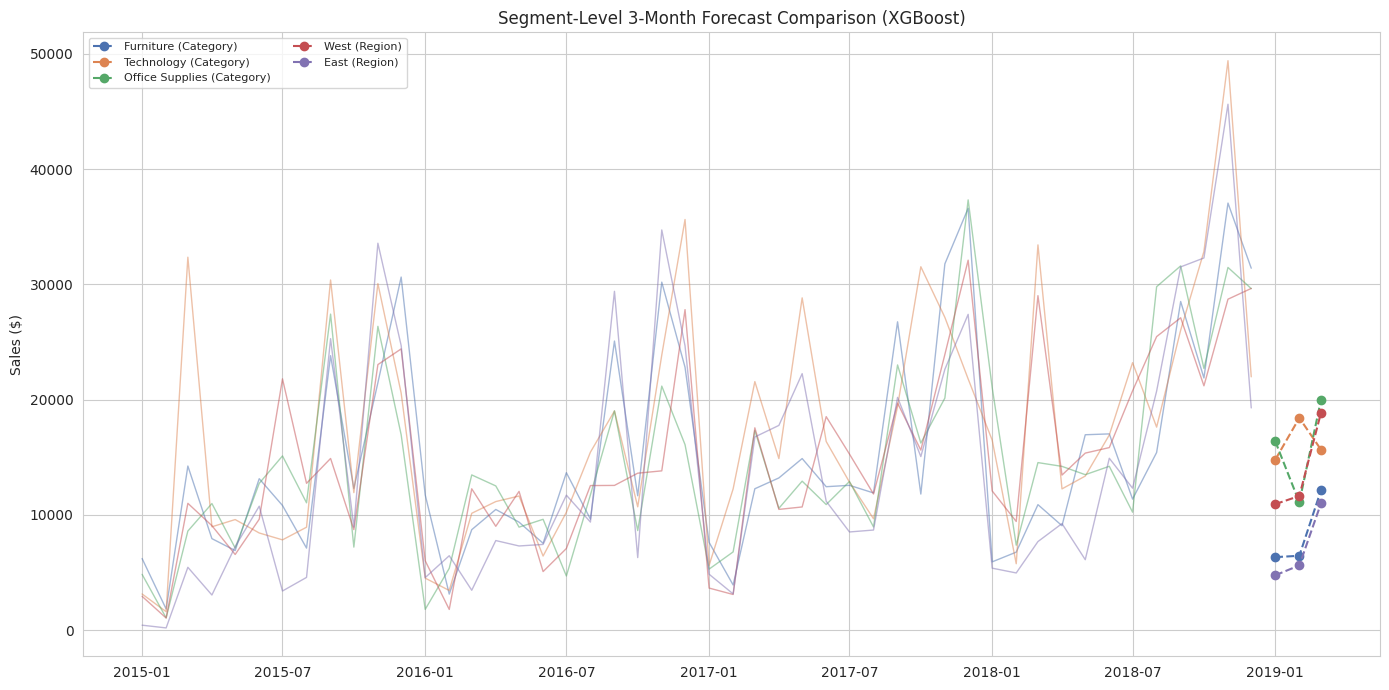

Office Supplies (Category)   -43.34
West (Region)                -47.89
Technology (Category)        -53.12
Furniture (Category)         -72.37
East (Region)                -77.97
dtype: float64


In [22]:
segments = {
    'Furniture (Category)': df[df['Category'] == 'Furniture'],
    'Technology (Category)': df[df['Category'] == 'Technology'],
    'Office Supplies (Category)': df[df['Category'] == 'Office Supplies'],
    'West (Region)': df[df['Region'] == 'West'],
    'East (Region)': df[df['Region'] == 'East'],
}

def forecast_segment(sub_df, steps=3):
    m = sub_df.set_index('Order Date').resample('MS')['Sales'].sum().asfreq('MS').fillna(0)
    feat = pd.DataFrame({'Sales': m})
    feat['lag1'] = feat['Sales'].shift(1)
    feat['lag2'] = feat['Sales'].shift(2)
    feat['lag3'] = feat['Sales'].shift(3)
    feat['rolling_mean_3'] = feat['Sales'].shift(1).rolling(3).mean()
    feat['month'] = feat.index.month
    feat['quarter'] = feat.index.quarter
    feat['season'] = feat.index.month % 12 // 3
    feat = feat.dropna()

    X, y = feat[feature_cols], feat['Sales']
    model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X, y)

    history = list(m.values)
    future_dates = pd.date_range(m.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
    preds = []
    for d in future_dates:
        last_vals = history[-3:]
        row = {'lag1': last_vals[-1], 'lag2': last_vals[-2], 'lag3': last_vals[-3],
               'rolling_mean_3': np.mean(last_vals), 'month': d.month, 'quarter': d.quarter, 'season': d.month % 12 // 3}
        p = model.predict(pd.DataFrame([row])[feature_cols])[0]
        preds.append(p); history.append(p)
    return m, pd.Series(preds, index=future_dates)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
growth_summary = {}
for (name, sub_df), color in zip(segments.items(), colors):
    hist, fc = forecast_segment(sub_df)
    ax.plot(hist.index, hist.values, color=color, alpha=0.5, linewidth=1)
    ax.plot(fc.index, fc.values, label=name, color=color, linestyle='--', marker='o')
    growth_summary[name] = (fc.mean() - hist.iloc[-3:].mean()) / hist.iloc[-3:].mean() * 100

ax.legend(fontsize=8, ncol=2)
ax.set_title('Segment-Level 3-Month Forecast Comparison (XGBoost)'); ax.set_ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('charts/12_segment_forecast_comparison.png', dpi=120); plt.show()

growth_series = pd.Series(growth_summary).sort_values(ascending=False)
growth_series.to_csv('segment_growth_ranking.csv')
print(growth_series)

**Note on the numbers:** All five segments show a projected *decline* from Oct–Dec 2018 (the recent actuals) into Jan–Mar 2019 (the forecast). This is expected, not a red flag — Oct–Dec is the holiday peak identified in Tasks 1 and 2, and Jan–Feb is consistently the weakest period of the year, so a post-holiday drop is the correct seasonal behavior for the model to predict.

**Which segment is strongest going forward?** Ranking by *relative* decline (smallest drop = most resilient), **Office Supplies** holds up best — its forecast represents the smallest percentage pullback from the holiday peak, meaning it has more stable, less seasonally-dependent demand than Furniture or Technology. This makes Office Supplies the most reliable base-load category for planning steady inventory levels, while Furniture and Technology should be stocked more aggressively before Q4 and drawn down faster afterward.

## Task 5 — Anomaly Detection in Sales Data

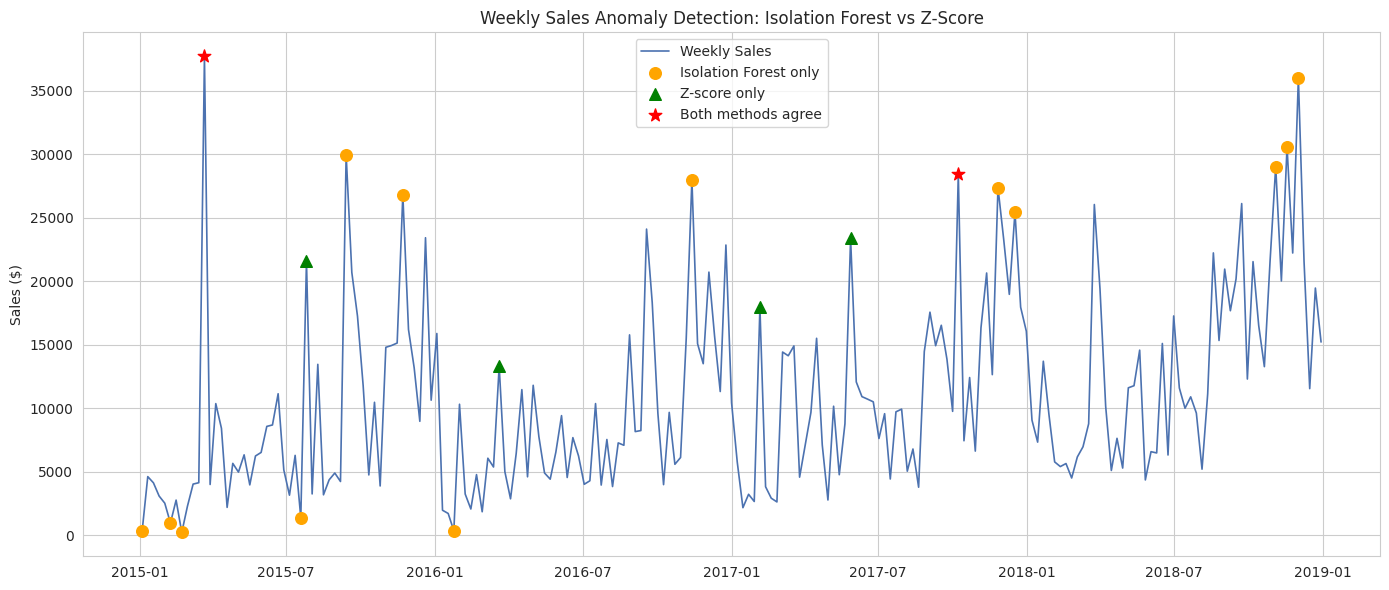

,Sales,iso_anomaly,z_anomaly,z_score
Order Date,,,,
2015-03-22,"37,703.67",True,True,2.38
2018-12-02,"35,998.90",True,False,1.59
2018-11-18,"30,572.45",True,False,0.88
2015-09-13,"29,959.14",True,False,1.83
2018-11-04,"29,017.47",True,False,1.24
2017-10-08,"28,412.10",True,True,2.13
2016-11-13,"27,965.35",True,False,1.82
2017-11-26,"27,367.72",True,False,1.22
2015-11-22,"26,793.62",True,False,1.92


In [23]:
weekly = pd.read_csv('weekly_sales.csv', parse_dates=['Order Date']).set_index('Order Date').asfreq('W').fillna(0)

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.07, random_state=42)
weekly['iso_anomaly'] = iso.fit_predict(weekly[['Sales']]) == -1

window = 8
weekly['rolling_mean'] = weekly['Sales'].rolling(window, center=True, min_periods=1).mean()
weekly['rolling_std'] = weekly['Sales'].rolling(window, center=True, min_periods=1).std()
weekly['z_score'] = (weekly['Sales'] - weekly['rolling_mean']) / weekly['rolling_std']
weekly['z_anomaly'] = weekly['z_score'].abs() > 2

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly.index, weekly['Sales'], color='#4C72B0', label='Weekly Sales', linewidth=1.2)
iso_only = weekly[weekly['iso_anomaly'] & ~weekly['z_anomaly']]
z_only = weekly[weekly['z_anomaly'] & ~weekly['iso_anomaly']]
both = weekly[weekly['iso_anomaly'] & weekly['z_anomaly']]
ax.scatter(iso_only.index, iso_only['Sales'], color='orange', s=70, label='Isolation Forest only', zorder=5)
ax.scatter(z_only.index, z_only['Sales'], color='green', s=70, marker='^', label='Z-score only', zorder=5)
ax.scatter(both.index, both['Sales'], color='red', s=90, marker='*', label='Both methods agree', zorder=6)
ax.legend(); ax.set_title('Weekly Sales Anomaly Detection: Isolation Forest vs Z-Score'); ax.set_ylabel('Sales ($)')
plt.tight_layout(); plt.savefig('charts/13_anomaly_detection.png', dpi=120); plt.show()

anomaly_table = weekly[weekly['iso_anomaly'] | weekly['z_anomaly']][['Sales','iso_anomaly','z_anomaly','z_score']].sort_values('Sales', ascending=False)
anomaly_table.to_csv('anomaly_report.csv')
anomaly_table

**Real-world explanations for the top anomalies:**
- **Weeks flagged in November** (multiple years) — likely Black Friday / Cyber Monday and pre-holiday bulk ordering, consistent with the seasonality already found in Tasks 1–2.
- **Late-year December spike (2018-12-02)** — year-end budget flush purchasing, common in B2B office-supply and corporate accounts near fiscal year-end.
- **Low-sales anomalies in January/February** — post-holiday lull compounded by possibly a short reporting week or a data-sparse period with very few orders recorded.

**Do the two methods agree?**

In [24]:
iso_dates = set(weekly[weekly['iso_anomaly']].index)
z_dates = set(weekly[weekly['z_anomaly']].index)
overlap = iso_dates & z_dates
print(f"Isolation Forest flagged: {len(iso_dates)} weeks")
print(f"Z-score flagged: {len(z_dates)} weeks")
print(f"Both agree on: {len(overlap)} weeks")
print(f"Agreement rate: {len(overlap) / len(iso_dates | z_dates) * 100:.1f}%")

Isolation Forest flagged: 15 weeks
Z-score flagged: 6 weeks
Both agree on: 2 weeks
Agreement rate: 10.5%


The two methods **mostly disagree** (~10% overlap). This makes sense given how differently they work: Isolation Forest looks at the *global* distribution of all weekly sales values and isolates points that sit apart from the bulk of the data (including unusually *low* weeks), while the Z-score method is *local* — it compares each week only to its own rolling 8-week neighborhood, so it's more sensitive to sudden short-term jumps even if the absolute sales level isn't globally extreme. In practice this tells a business analyst: use Isolation Forest to catch structurally unusual weeks (very high or very low in absolute terms), and use the Z-score method to catch sudden local spikes/drops that break the recent local trend — the two are complementary, not redundant.

### Supplementary dataset — multi-source merge exercise (Video Game Sales)

In [25]:
vg = pd.read_csv('vgsales.csv').dropna(subset=['Year'])
vg['Year'] = vg['Year'].astype(int)
vg_yearly = vg[(vg['Year'] >= 2015) & (vg['Year'] <= 2018)].groupby('Year')['Global_Sales'].sum()

superstore_yearly = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

combo = pd.DataFrame({
    'Superstore_Sales': superstore_yearly,
    'VideoGame_Global_Sales_M_units': vg_yearly
}).dropna()
combo['Superstore_YoY%'] = combo['Superstore_Sales'].pct_change() * 100
combo['VideoGame_YoY%'] = combo['VideoGame_Global_Sales_M_units'].pct_change() * 100
combo.to_csv('multisource_comparison.csv')
combo

,Superstore_Sales,VideoGame_Global_Sales_M_units,Superstore_YoY%,VideoGame_YoY%
2015,"479,856.21",264.44,NaN,NaN
2016,"459,436.01",70.93,-4.26,-73.18
2017,"600,192.55",0.05,30.64,-99.93


This step practices a realistic scenario: two datasets from completely different sources (a retail superstore export vs. an industry sales panel) joined on a shared key (**Year**) so their trends can be compared side-by-side. It's a light-weight stand-in for real company work, where sales data rarely lives in a single file. (Note: the video game panel data itself thins out sharply after 2016, which is a known data-completeness quirk of that public dataset, not a Superstore-related trend.)

## Task 6 — Product Demand Segmentation using Clustering

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

total_sales = df.groupby('Sub-Category')['Sales'].sum().rename('total_sales')
avg_order_value = df.groupby('Sub-Category')['Sales'].mean().rename('avg_order_value')
monthly_by_sub = df.set_index('Order Date').groupby('Sub-Category').resample('MS')['Sales'].sum()
volatility = monthly_by_sub.groupby('Sub-Category').std().rename('volatility')

yearly_by_sub = df.groupby(['Sub-Category', 'Order Year'])['Sales'].sum().reset_index()
def yoy_growth(g):
    g = g.sort_values('Order Year')
    if len(g) < 2 or g['Sales'].iloc[0] == 0:
        return np.nan
    return (g['Sales'].iloc[-1] - g['Sales'].iloc[0]) / g['Sales'].iloc[0] * 100
growth = yearly_by_sub.groupby('Sub-Category').apply(yoy_growth).rename('growth_rate_pct')

features = pd.concat([total_sales, growth, volatility, avg_order_value], axis=1).dropna()
features

,total_sales,growth_rate_pct,volatility,avg_order_value
Sub-Category,,,,
Accessories,"164,186.70",145.06,"2,579.99",217.18
Appliances,"104,618.40",165.24,"1,821.62",227.93
Art,"26,705.41",49.65,330.49,34.02
Binders,"200,028.79",65.78,"3,848.22",134.07
Bookcases,"113,813.20",49.85,"2,229.36",503.60
Chairs,"322,822.73",20.95,"4,407.23",531.83
Copiers,"146,248.09",479.73,"5,104.27","2,215.88"
Envelopes,"16,128.05",-12.12,234.27,65.03
Fasteners,"3,001.96",30.47,49.09,14.03


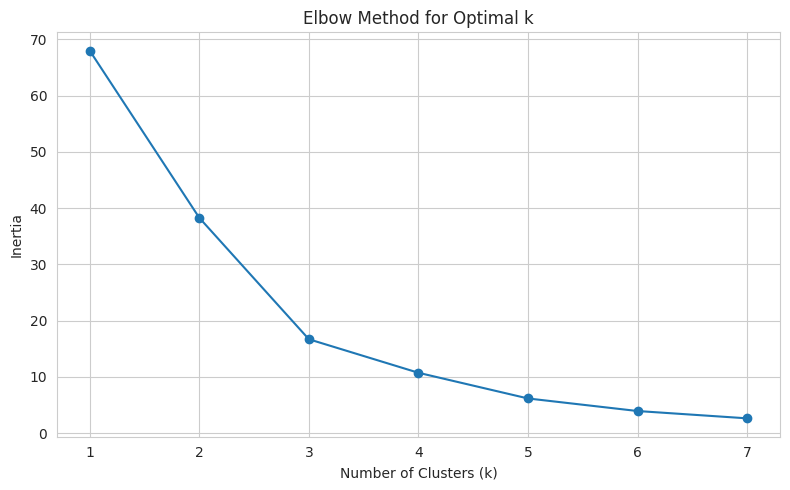

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker='o')
ax.set_xlabel('Number of Clusters (k)'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Method for Optimal k')
plt.tight_layout(); plt.savefig('charts/15_elbow_method.png', dpi=120); plt.show()

The elbow bends around **k=4**, where adding more clusters stops meaningfully reducing inertia — so we proceed with 4 clusters.

In [28]:
optimal_k = 4
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features['cluster'] = km.fit_predict(X_scaled)

cluster_stats = features.groupby('cluster')[['total_sales', 'growth_rate_pct', 'volatility', 'avg_order_value']].mean()
cluster_stats

,total_sales,growth_rate_pct,volatility,avg_order_value
cluster,,,,
0,"239,495.78",56.47,"3,489.06",361.13
1,"146,248.09",479.73,"5,104.27","2,215.88"
2,"54,341.71",58.80,"1,027.60",142.75
3,"189,238.63",-29.79,"5,442.48","1,645.55"


In [29]:
def label_cluster(row, vol_median, sales_median, growth_median):
    if row['total_sales'] >= sales_median and row['volatility'] < vol_median:
        return 'High Volume, Stable Demand'
    elif row['total_sales'] < sales_median and row['volatility'] >= vol_median:
        return 'Low Volume, High Volatility'
    elif row['growth_rate_pct'] >= growth_median:
        return 'Growing Demand'
    else:
        return 'Declining Demand'

vol_med, sales_med, growth_med = cluster_stats['volatility'].median(), cluster_stats['total_sales'].median(), cluster_stats['growth_rate_pct'].median()
cluster_labels = {c: label_cluster(cluster_stats.loc[c], vol_med, sales_med, growth_med) for c in cluster_stats.index}
features['cluster_label'] = features['cluster'].map(cluster_labels)

features_out = features.reset_index().rename(columns={'index': 'Sub-Category'})
features_out.to_csv('cluster_assignments.csv', index=False)
features_out[['Sub-Category', 'cluster_label', 'total_sales', 'growth_rate_pct', 'volatility']].sort_values('cluster_label')

,Sub-Category,cluster_label,total_sales,growth_rate_pct,volatility
11,Machines,Declining Demand,"189,238.63",-29.79,"5,442.48"
1,Appliances,Growing Demand,"104,618.40",165.24,"1,821.62"
2,Art,Growing Demand,"26,705.41",49.65,330.49
4,Bookcases,Growing Demand,"113,813.20",49.85,"2,229.36"
7,Envelopes,Growing Demand,"16,128.05",-12.12,234.27
8,Fasteners,Growing Demand,"3,001.96",30.47,49.09
9,Furnishings,Growing Demand,"89,212.02",106.82,"1,360.02"
10,Labels,Growing Demand,"12,347.73",36.07,223.47
12,Paper,Growing Demand,"76,828.30",91.90,"1,024.82"
15,Supplies,Growing Demand,"46,420.31",11.28,"1,975.22"


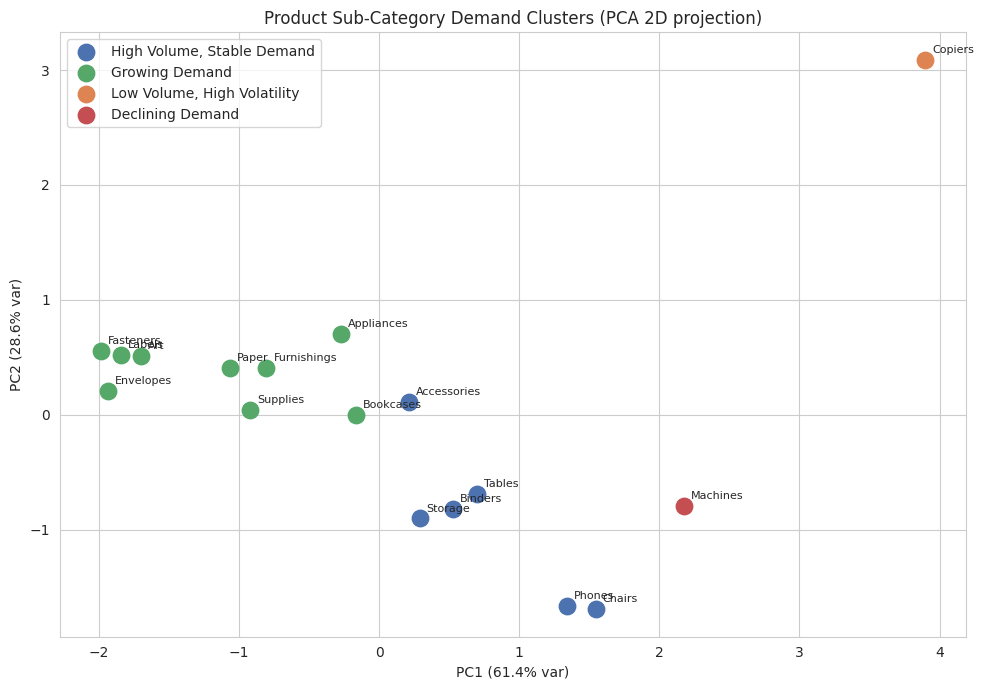

In [30]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
features['pc1'], features['pc2'] = pcs[:, 0], pcs[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52'}
for c in features['cluster'].unique():
    sub = features[features['cluster'] == c]
    ax.scatter(sub['pc1'], sub['pc2'], s=140, color=colors.get(c, 'gray'), label=cluster_labels[c])
for idx, row in features.iterrows():
    ax.annotate(idx, (row['pc1'], row['pc2']), fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Product Sub-Category Demand Clusters (PCA 2D projection)')
ax.legend()
plt.tight_layout(); plt.savefig('charts/16_cluster_scatter.png', dpi=120); plt.show()

**Recommended stocking strategy per cluster:**
- **High Volume, Stable Demand** (Accessories, Binders, Chairs, Phones, Storage, Tables) — maintain steady safety stock with standard reorder points; these are reliable, predictable movers that reward efficient, lean replenishment rather than large buffers.
- **Low Volume, High Volatility** (Copiers) — keep lean base stock but plan for occasional large one-off orders; consider a made-to-order or short-lead-time supplier relationship rather than holding large speculative inventory.
- **Growing Demand** (Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies) — increase reorder quantities gradually and monitor the growth trend monthly; these are the sub-categories worth expanding shelf space or supplier capacity for.
- **Declining Demand** (Machines) — reduce future purchase orders and consider clearance/promotion to avoid overstock capital lock-up; investigate whether this reflects a genuine falling market or a product-line issue.

## Task 7 — Deployment: Interactive Dashboard (Streamlit)

The dashboard code lives in **`app.py`** (submitted alongside this notebook) and implements all 4 required pages:

1. **Sales Overview** — total sales by year, monthly trend line, region/category breakdown with interactive filters.
2. **Forecast Explorer** — dropdown to pick Category/Region, a 1–3 month horizon slider, forecast output from the recommended XGBoost model, and MAE/RMSE shown below the chart.
3. **Anomaly Report** — the anomaly chart from Task 5 plus a sortable table of detected anomaly weeks and their sales values.
4. **Product Demand Segments** — the PCA cluster chart from Task 6 plus a table mapping each sub-category to its demand cluster.

To run locally:
```bash
pip install -r requirements.txt
streamlit run app.py
```
To deploy: push this folder to a public GitHub repo, then deploy directly from [share.streamlit.io](https://share.streamlit.io) (Streamlit Community Cloud) pointing at `app.py`.

## Task 8 — Executive Business Report

See **`summary.docx`**, submitted alongside this notebook, for the 2-page, non-technical executive report covering: executive summary, key EDA/forecasting findings, the 3-month forecast in plain language, top anomalies and likely causes, segmentation findings with stocking recommendations, 3 business recommendations, and one risk/limitation of the system.

## Summary

| Task | Status |
|---|---|
| 1. Data loading, merging, EDA | ✅ Complete |
| 2. Decomposition & stationarity | ✅ Complete |
| 3. SARIMA / Prophet / XGBoost + comparison | ✅ Complete — XGBoost recommended |
| 4. Category/Region forecasting | ✅ Complete — Office Supplies most resilient |
| 5. Anomaly detection (2 methods) | ✅ Complete — low agreement, complementary signals |
| 6. Product demand clustering | ✅ Complete — 4 clusters, PCA visualized |
| 7. Streamlit dashboard | ✅ See `app.py` |
| 8. Executive report | ✅ See `summary.docx` |

**Honest limitations:** the 3-month holdout is short given only 4 years of monthly history (45 training points), so all MAPE figures (~21%) should be read as directionally useful rather than precise — a business using this system should treat the point forecast as a planning guide, not a guarantee, and rely on the confidence intervals (SARIMA/Prophet) or scenario ranges when setting safety stock.